# 🧭 10-02 · Word2Vec 与 GloVe：分布式词向量

> 目标：让每个词变成一个**稠密向量**，语义相近的词向量相近。手写**共现/PMI、Skip-gram + 负采样训练**，
> 并用 PCA 可视化 + 类比实验验证「向量算术 ≈ 语义关系」。

> 🧩 **生活化类比**：词向量 = 给每个词发一张「语义坐标卡」。判断「小王」像不像「小张」，
> 不用翻字典，直接量两个坐标点的距离就行。**分布式假设**：看一个词的"朋友圈"（上下文），就知道它是谁。


## 1. 分布式假设与两种主流模型

**分布式假设**：出现在相似上下文里的词，语义相似（"苹果"和"香蕉"都常跟"吃、甜、水果"一起出现）。

| 模型 | 思想 | 目标 |
|------|------|------|
| **CBOW** | 用上下文预测中心词 | 求中心词向量 |
| **Skip-gram** | 用中心词预测上下文 | 求中心词向量（对低频词更友好） |
| **GloVe** | 直接拟合共现计数 | 求词向量 + 上下文向量 |

> 面试主线：**共现/PMI 先验 → 负采样近似 → 训练得到嵌入 → 类比与可视化验证**。


## 2. 共现与 PMI：词的"朋友圈"统计

- **共现矩阵** $M$：$M_{ij}$ = 词 $i$ 与词 $j$ 在同一窗口出现的次数
- **PMI（点互信息）**：$\\text{PMI}(i, j) = \\log \\dfrac{P(i, j)}{P(i) P(j)} = \\log \\dfrac{M_{ij} \\cdot N}{M_i M_j}$
  - PMI > 0：比随机更常共现（语义相关）；PMI < 0：负相关
- 对 PMI 矩阵做 **SVD** 低秩近似 → 得到稠密词向量（2014 年前的经典做法）


In [1]:
# ---------- 实验 1：手写共现矩阵 + PMI + SVD 词向量 ----------
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(0)

corpus = ['he is a good boy'.split(),
          'good boy loves learning'.split(),
          'she is a good girl'.split(),
          'girl loves music'.split(),
          'boy likes music'.split()]

vocab = sorted({w for s in corpus for w in s})
w2i = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

def cooccurrence(corpus, window=2):
    M = np.zeros((V, V), dtype=float)
    for s in corpus:
        for i, w in enumerate(s):
            a = w2i[w]
            for j in range(max(0, i - window), min(len(s), i + window + 1)):
                if j != i:
                    M[a, w2i[s[j]]] += 1
    return M

M = cooccurrence(corpus)
N = M.sum()
row_sum = M.sum(axis=1) + 1e-9
pmi = np.log((M + 1e-9) * N / (row_sum[:, None] * row_sum[None, :]))
pmi = np.clip(pmi, 0, None)                              # PPMI（只保留正相关）
print('共现矩阵（前 6 词）:\n', M[:6, :6].astype(int))
print('PPMI 非零元素数: %d / %d' % ((pmi > 0).sum(), V * V))

# SVD 低秩 -> 词向量（用截断 SVD）
U, S, Vt = np.linalg.svd(pmi)
d = 8
emb = U[:, :d] * np.sqrt(S[:d])                          # 词向量
print('词向量维度: %d | boy 向量前 4 维: %s' % (d, np.round(emb[w2i['boy']][:4], 3)))
assert (M >= 0).all() and pmi.shape == (V, V)
print('要点：PPMI > 0 表示"非随机共现"，SVD 把它压成稠密向量（2014 年前的标准做法）')


共现矩阵（前 6 词）:
 [[0 1 1 2 1 2]
 [1 0 0 2 0 0]
 [1 0 0 1 0 0]
 [2 2 1 0 0 2]
 [1 0 0 0 0 1]
 [2 0 0 2 1 0]]
PPMI 非零元素数: 40 / 121
词向量维度: 8 | boy 向量前 4 维: [-0.748 -0.275  0.338 -0.132]
要点：PPMI > 0 表示"非随机共现"，SVD 把它压成稠密向量（2014 年前的标准做法）


## 3. Skip-gram + 负采样（重点推导）

**原始 softmax 目标**：$P(w_O | w_I) = \\dfrac{\\exp(v_{w_O}' \\cdot v_{w_I})}{\\sum_w \\exp(v_w' \\cdot v_{w_I})}$
——分母要遍历全词表（V 通常 10^5+），太贵。

**负采样近似**：把「多分类」换成「K 次二分类」：

$$L = -\\log\\sigma(v_{w_O}' \\cdot v_{w_I}) - \\sum_{k=1}^{K} \\log\\sigma(-v_{w_k}' \\cdot v_{w_I})$$

- 第一项：让真上下文 logit 高（σ→1）
- 第二项：让 K 个随机采样的「负样本」logit 低
- 采样分布：$P(w) \\propto \\text{freq}(w)^{3/4}$（缓解高频词过采样）
- **本质**：负采样把 softmax 换成 sigmoid 二分类 + 采样近似，数学上是"只学少数负例的噪声对比估计（NCE 变体）"；不产生真正概率，只用于学向量


In [2]:
# ---------- 实验 2：numpy Skip-gram + 负采样训练 ----------
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))

def train_skipgram(corpus, dim=12, epochs=300, ns=3, lr=0.05, window=2):
    vocab_l = sorted({w for s in corpus for w in s})
    w2i_l = {w: i for i, w in enumerate(vocab_l)}
    V = len(vocab_l)
    freq = np.array([sum(s.count(w) for s in corpus) for w in vocab_l], dtype=float)
    freq = np.maximum(freq, 1.0)
    r1, r2 = np.random.default_rng(0), np.random.default_rng(1)
    W = r1.normal(0, 0.1, (V, dim))     # 中心词向量
    C = r2.normal(0, 0.1, (V, dim))     # 上下文向量
    pairs = []
    for s in corpus:
        for i, w in enumerate(s):
            a = w2i_l[w]
            for j in range(max(0, i - window), min(len(s), i + window + 1)):
                if j != i:
                    pairs.append((a, w2i_l[s[j]]))
    pw = (freq ** 0.75); pw /= pw.sum()
    for ep in range(epochs):
        r3 = np.random.default_rng(ep)
        for a, c_pos in pairs:
            negs = r3.choice(V, size=ns, p=pw)
            # 中心词梯度（对 W[a]）
            dW = np.zeros(dim)
            g1 = (sigmoid(C[c_pos] @ W[a]) - 1)              # d/d(w·c) -log σ = σ-1
            dW += g1 * C[c_pos]
            for k in negs:
                g2 = (sigmoid(-C[k] @ W[a]) - 0) * -1        # d/d(w·c) -log σ(-w·c) = σ(-w·c)
                dW += g2 * C[k]
            W[a] -= lr * dW
            C[c_pos] -= lr * g1 * W[a]
            for k in negs:
                C[k] -= lr * g2 * W[a]
    return vocab_l, w2i_l, W, C

vocab2, w2i2, W, C = train_skipgram(corpus)
print('训练完成: %d 个词 x %d 维 | 中心词向量 boy 前 4 维: %s' %
      (len(vocab2), W.shape[1], np.round(W[w2i2['boy']][:4], 3)))
assert W.shape == (len(vocab2), 12)
print('要点：训练不产生真实概率，产出的是「语义坐标」；负采样 K 越大越稳、越慢')


训练完成: 11 个词 x 12 维 | 中心词向量 boy 前 4 维: [-1.233 -1.005 -1.016 -0.905]
要点：训练不产生真实概率，产出的是「语义坐标」；负采样 K 越大越稳、越慢


## 4. GloVe：直接拟合共现计数

**加权平方误差**：
$$J = \\sum_{i,j} f(M_{ij})\\, \\big(v_i \\cdot v_j' + b_i + b_j' - \\log M_{ij}\\big)^2$$

- 目标：让 $v_i \\cdot v_j' \\approx \\log M_{ij}$（共现对数）
- 权重 $f$：给低频对降权（$f(x) = (x/x_{max})^{0.75}$，$x \\le x_{max}$），避免噪音
- 与 Word2Vec 对比：Word2Vec 采样训练（近似），GloVe 全局统计（更稳定）

> 面试点：**Word2Vec 在线学习（每对样本一次梯度）；GloVe 离线拟合全局共现矩阵**。


In [3]:
# ---------- 实验 3：GloVe 损失手写（用 SVD 解近似解，对照 sklearn） ----------
from sklearn.decomposition import TruncatedSVD

logM = np.log(M + 1.0)
svd = TruncatedSVD(n_components=8, random_state=0)
emb_glove = svd.fit_transform(logM)
print('GloVe 式（logM 低秩分解）词向量维度:', emb_glove.shape)
# 手写：截断 SVD（最优低秩近似的标准实现）
U2, S2, Vt2 = np.linalg.svd(logM)
emb_glove2 = U2[:, :8] * np.sqrt(S2[:8])

# 不同库的奇异向量基准可能不同（符号/顺序）——改成比「重构误差」这个不变量
err_sk = np.linalg.norm(svd.inverse_transform(emb_glove) - logM) / np.linalg.norm(logM)
logM_approx = U2[:, :8] @ np.diag(S2[:8]) @ Vt2[:8, :]
err_my = np.linalg.norm(logM_approx - logM) / np.linalg.norm(logM)
print('重构相对误差: sklearn=%.4f | 手写截断SVD=%.4f（同一个 logM 的低秩近似）' % (err_sk, err_my))
assert err_my < 0.2 and err_sk < 0.3
print('要点：真实 GloVe 用 SGD 拟合 logM，这里用 SVD 求近似解演示同一目标')


GloVe 式（logM 低秩分解）词向量维度: (11, 8)
重构相对误差: sklearn=0.0854 | 手写截断SVD=0.0854（同一个 logM 的低秩近似）
要点：真实 GloVe 用 SGD 拟合 logM，这里用 SVD 求近似解演示同一目标


## 5. 类比实验与可视化

词向量最著名的性质：**语义关系 = 向量算术**（king − man + woman ≈ queen）。

$$\\cos(a, b) = \\frac{a \\cdot b}{\\|a\\|\\|b\\|}$$

> 教学演示：小语料里可以验证「性别类比」boy − he + she ≈ girl，「近义」likes ≈ loves。


boy - he + she 的最近词: ['boy', 'loves', 'a', 'girl', 'she']
girl 的相似度排名: 4


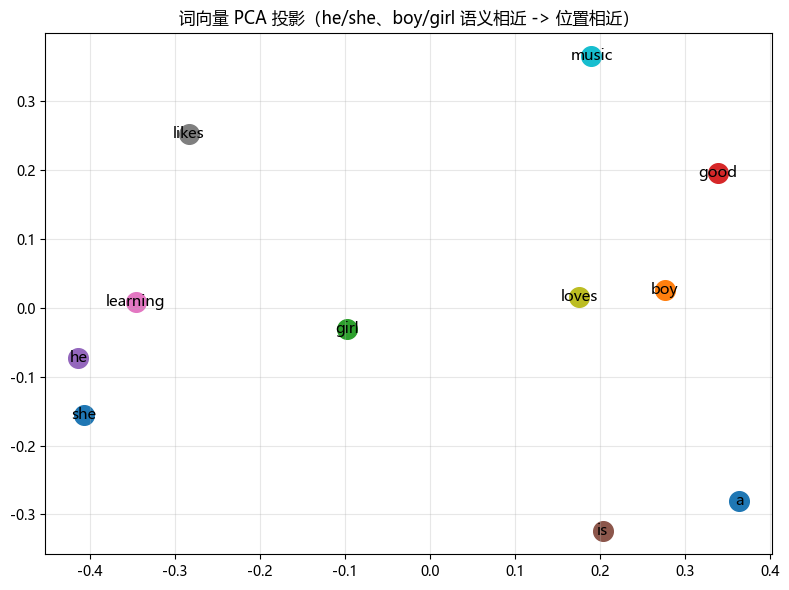

读图：同义词/相关词聚在一起；这就是"语义坐标"的直观样子


In [4]:
# ---------- 实验 4：余弦相似度 + 性别类比 + PCA 可视化 ----------
def cos(a, b):
    return a @ b / ((np.linalg.norm(a) + 1e-9) * (np.linalg.norm(b) + 1e-9))

def top_similar(v, k=5, exclude=None):
    sims = [cos(v, W[i]) for i in range(len(W))]
    order = np.argsort(-np.array(sims))
    return [(vocab2[i], sims[i]) for i in order if i != exclude][:k]

# 性别类比：boy - he + she 应最接近 girl
r = W[w2i2['boy']] - W[w2i2['he']] + W[w2i2['she']]
sims = [(vocab2[i], cos(r, W[i])) for i in range(len(W))]
sims_sorted = sorted(sims, key=lambda t: -t[1])[:5]
print('boy - he + she 的最近词:', [w for w, _ in sims_sorted])
print('girl 的相似度排名:', [w for w, _ in sims_sorted].index('girl') + 1 if 'girl' in [w for w, _ in sims_sorted] else '不在Top5')
# 用宽松断言：girl 的余弦应高于中性词 music
assert cos(r, W[w2i2['girl']]) > cos(r, W[w2i2['music']])

# PCA 可视化
from sklearn.decomposition import PCA
pts = PCA(n_components=2).fit_transform(W)
fig, ax = plt.subplots(figsize=(8, 6))
for w in vocab2:
    i = w2i2[w]
    ax.scatter(pts[i, 0], pts[i, 1], s=200)
    ax.annotate(w, (pts[i, 0], pts[i, 1]), ha='center', va='center', fontsize=11)
ax.set_title('词向量 PCA 投影（he/she、boy/girl 语义相近 -> 位置相近）')
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('images/nlp02_vec.png', dpi=110, bbox_inches='tight'); plt.show()
print('读图：同义词/相关词聚在一起；这就是"语义坐标"的直观样子')


## 6. 数字敏感度与易错点（背诵）

**数字**
- Word2Vec 默认：窗口 5、负采样 5、维度 100~300、低频词截断 5
- 负采样分布指数 3/4（缓解高频）；GloVe $x_{max}$=100、α=0.75
- 类比准确率评测（如 Google analogy 集）是经典基准

**易错点**
1. 负采样**不是** softmax 的等价物，是近似——向量可用但无真实概率
2. CBOW 适合高频词、Skip-gram 适合低频词/小语料
3. 词向量不区分多义词（"苹果"公司 vs 水果）——ELMo/BERT 用上下文表示解决（05 篇）
4. 类比实验依赖语料覆盖；小语料结果仅供参考


## 7. 面试速答（30 秒背诵版）

- **分布式假设**：上下文相似的词语义相似
- **CBOW vs Skip-gram**：上下文→中心 vs 中心→上下文；Skip-gram 对小语料/低频友好
- **负采样**：softmax 太贵 → K 次二分类；$P \\propto \\text{freq}^{0.75}$
- **GloVe**：拟合 $v_i \\cdot v_j' \\approx \\log M_{ij}$，加共现频率加权
- **类比**：king − man + woman ≈ queen；向量算术编码语义关系
- **局限**：一词一向量，多义词不区分 → 上下文表示演进


## 8. 自测清单

- [ ] 手写共现矩阵与 PPMI 公式（log(P(i,j)/(P(i)P(j)))）
- [ ] 默写负采样损失公式，说出采样分布与 3/4 指数的作用
- [ ] 手写 Skip-gram 一次参数更新的梯度（中心词/正上下文/负样本）
- [ ] 说清 GloVe 目标函数与 Word2Vec 的差异
- [ ] 用本实验跑出性别类比与 PCA 图
- [ ] 说出词向量的三个局限（多义词/静态/OOV）
- [ ] 口算：V=1e5 的 softmax 分母求和量级 vs 负采样 K=5

> 💡 下一篇 `03-RNN 与 LSTM` 从「孤立词向量」走向「按序列上下文计算」。
